<a href="https://colab.research.google.com/github/NathalieKa/Python101/blob/main/LogistischeRegressionSklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Einführung Machine Learning
### Sommersemester 2026
Prof. Dr. Heiner Giefers

# Logistische Regression mit `scikit-learn`

In diesem Notebook geht es darum, wie man mit `scikit-learn` ein logistisches Regressionsmodell aufbaut, trainiert, auswertet und anwendet. Wir nutzen dazu einen kleinen Datensatz über Personen mit den Merkmalen Größe und Gewicht, und der Zielvariable biologisches Geschlecht.

## 1. Daten einlesen und vorbereiten
Wir beginnen mit dem Einlesen des CSV-Datensatzes `groesse_gewicht.csv`, der die Spalten `Geschlecht`, `Groesse` und `Gewicht` enthält.



---

Der zentrale Unterschied: Lineare Regression sagt einen kontinuierlichen Wert voraus ("wie schwer?"). Logistische Regression sagt eine Klasse voraus ("welche von zwei Gruppen?"). Hier: Aus Größe und Gewicht soll das Modell das biologische Geschlecht vorhersagen.


---



In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Daten einlesen
df = pd.read_csv("groesse_gewicht.csv")
df.columns = ["Geschlecht", "Groesse", "Gewicht"] #setzt diese spalten ein
df.head() # zeige die ersten 5 zeilen

,Geschlecht,Groesse,Gewicht
0,1,1.875714,109.720985
1,1,1.747060,73.622732
2,1,1.882397,96.497550
3,1,1.821967,99.809504
4,1,1.774998,93.598619


## 2. Daten aufteilen und normalisieren

`scikit-learn` stellt wichtige Hilfsfunktionen bereit, um Daten für das Training von Modellen vorzubereiten. Zwei davon sind:

### `train_test_split`
Diese Funktion aus `sklearn.model_selection` ermöglicht es, den vorhandenen Datensatz zufällig in zwei Teilmengen aufzuteilen:
- **Trainingsdaten** (`X_train`, `y_train`) – werden zum Trainieren des Modells verwendet.
- **Testdaten** (`X_test`, `y_test`) – dienen zur unabhängigen Bewertung der Modellleistung.

Ein typischer Aufruf sieht so aus:
```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```
Dabei gibt `test_size=0.2` an, dass 20% der Daten als Testdaten reserviert werden.

**y = Das Zielwert / x = Die Eingaben**

### MinMaxScaler

Diese Funktion aus `sklearn.preprocessing` transformiert numerische Merkmale so, dass sie in einem festen Bereich – üblicherweise ([0, 1]) – liegen. Das ist besonders wichtig für Verfahren, die sensitiv auf Merkmalsskalen reagieren (z. B. logistische Regression, SVM, KNN).

Ein Beispiel:
```python
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
```

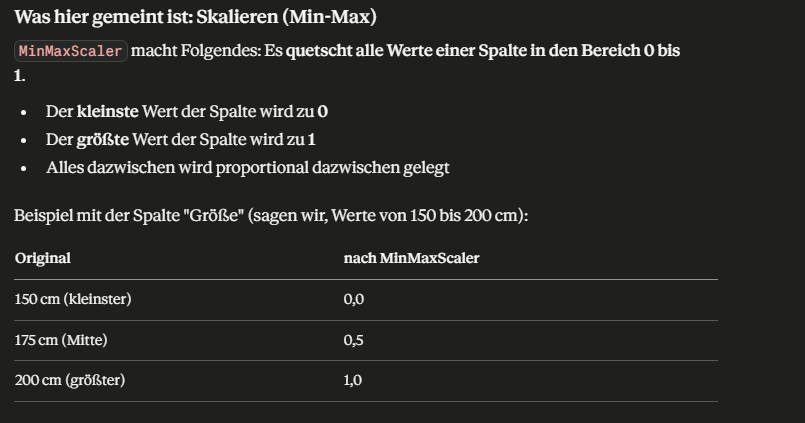

**Warum man das braucht
Größe (z.B. 150–200) und Gewicht (z.B. 50–100) haben verschiedene Zahlenbereiche. Viele Modelle – darunter die logistische Regression, die hier dran ist – reagieren empfindlich darauf. Sie würden dem Merkmal mit den größeren Zahlen automatisch mehr Bedeutung beimessen, nur weil die Zahlen größer sind, nicht weil es wichtiger ist. Nach dem Skalieren sind beide gleichberechtigt.**

### Wichtiger Hinweis zur Reihenfolge

> Um Datenlecks zu vermeiden, darf der Scaler nur mit den Trainingsdaten fit durchgeführt werden.

Die korrekte Reihenfolge lautet also:
```python
# 1. Daten aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 2. Nur Trainingsdaten fitten
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train) #umrechnen in 160 cm -> 0,5 bsp

# 3. Testdaten mit denselben Parametern transformieren
X_test_scaled = scaler.transform(X_test)
```
Wenn man stattdessen den Scaler direkt auf dem gesamten Datensatz fitten würde, könnten **Informationen aus den Testdaten unbeabsichtigt in das Modelltraining einfließen** – das nennt man **Data Leakage**. Dadurch würde die Bewertung des Modells auf den Testdaten zu optimistisch ausfallen.





---

Eine Sache: Er sucht in einer Zahlenspalte den kleinsten und den größten Wert. Mehr nicht. Den Rest rechnet er daraus.

Der Scaler merkt sich: "min = 150, max = 200". Mit diesen zwei Zahlen rechnet er dann alles auf 0–1 um.

Das Merken von min und max – das nennt man fit.
Das Umrechnen – das nennt man transform.

Die Testdaten sind die "Geheimprüfung". Das Modell darf sie nicht vorher kennen.
Aber: Wenn der Scaler beim fit (also beim Merken von min/max) auch die Testdaten anschaut, dann hat er heimlich reingespitzt. Er weiß jetzt etwas über die Testdaten (nämlich ihren Bereich).

* scaler – das Skalier-Werkzeug, das vorher schon fit auf den Trainingsdaten gemacht hat. Es hat sich also min und max der Trainingsdaten gemerkt.
* .transform(X_test) – rechnet die Testdaten X_test mit genau diesem gemerkten min/max um.
* X_test_scaled – die umgerechneten Testdaten landen in dieser neuen Variable.
 * X_test selbst bleibt unverändert.

---



In [3]:
# Aufteilen in X (Features) und y (Ziel)

X = df[["Groesse", "Gewicht"]].values #eingaben
y = df["Geschlecht"].values #ziel

# Aufteilen in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Skalieren
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train) #scaler
X_test_scaled = scaler.transform(X_test)

## 3. Modell mit `LogisticRegression` trainieren
Wir verwenden das Modell `LogisticRegression` aus `sklearn.linear_model`, um ein logistisches Regressionsmodell auf den Trainingsdaten zu trainieren.

In [4]:
from sklearn.linear_model import LogisticRegression

# Modell erzeugen und trainieren
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Modellkoeffizienten ansehen
model.coef_, model.intercept_

(array([[-1.15477866, 22.16978252]]), array([-9.85181285]))

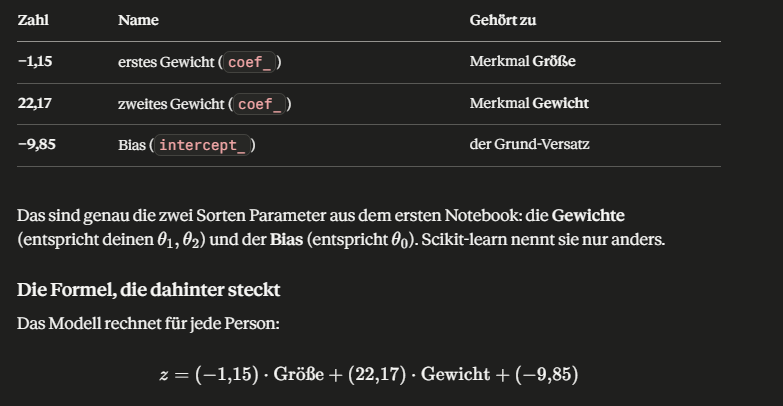

## 4. Vorhersagen und Wahrscheinlichkeiten
Mit `predict` können wir Klassenvorhersagen treffen, mit `predict_proba` erhalten wir Wahrscheinlichkeiten für beide Klassen.

In [5]:
# Vorhersage treffen
y_pred = model.predict(X_test_scaled) #Eine Entscheidung: 0 oder 1
y_proba = model.predict_proba(X_test_scaled) # Wie sicher es sich ist: eine Zahl zwischen 0 und 1

# Ausgabe beider Ergebnisse (nur die ersten 10)
list(zip(y_pred, y_proba[:, 1]))[:10]

[(np.int64(1), np.float64(0.7654700026191316)),
 (np.int64(1), np.float64(0.9722696358450371)),
 (np.int64(1), np.float64(0.7264670543623222)),
 (np.int64(1), np.float64(0.9961663620119013)),
 (np.int64(1), np.float64(0.9086292007493578)),
 (np.int64(0), np.float64(0.06781328331140257)),
 (np.int64(1), np.float64(0.7103318979208227)),
 (np.int64(0), np.float64(0.24448602288918414)),
 (np.int64(0), np.float64(0.007891005390103983)),
 (np.int64(0), np.float64(0.15978828684806914))]

## 5. Genauigkeit und Bewertung
Die Genauigkeit eines Klassifikationsmodells kann mit `accuracy_score` gemessen werden.

**Aufgabe:** Berechne die Genauigkeit des Modells auf den Testdaten.

In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred) #  y ergebnisse / y vorhersagen

print(accuracy)

# YOUR CODE HERE
#raise NotImplementedError()

0.914


## 6. Übung: Neue Eingabedaten klassifizieren
👉 **Aufgabe:** Erstelle ein neues Beispiel mit Größe = 1.70 m und Gewicht = 70 kg. Verwende das trainierte Modell, um eine Klassenvorhersage zu treffen.

In [12]:
import numpy as np

person = np.array([[1.70, 70]])
person = scaler.transform(person)

result = model.predict(person)

print(result)


#raise NotImplementedError()

[0]
